# Thesis Main Findings - E1

# Logprobs Analysis

In [7]:
import json
from pathlib import Path
from collections import defaultdict

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1").is_dir())

ROSTER = [("Gemma-12B", "gemma4-12b"), ("Qwen3-VL-8B", "qwen3-vl-8b"),
          ("Ministral-3-14B", "ministral-3-14b"), ("Gemma-E4B", "gemma4-e4b"),
          ("Qwen3-VL-4B", "qwen3-vl-4b"), ("Ministral-3-8B", "ministral-3-8b")]

SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]
LABELS = ["0", "10", "100", "1K", "10K", "100K", "1M"]

# phrasing -> (which candidate counts as "liked", filename template)
PHRASING = {"like/scroll": ("like", "e1_results_{c}_logprobs.json"),
            "yes/no":      ("yes",  "e1_results_{c}_yesno_logprobs.json")}


def p_liked(slug, phrasing, condition):
    """Mean P(liked) per variant per engagement level.

    P is `prob_forced_choice` — the model's probability of the liking token *renormalised
    against its opposite*, so it answers "given it had to pick one, how far toward liking
    was it?" rather than being diluted by every other token in the vocabulary.

    Scale 0 comes from the baseline run (no engagement shown); 10..1M from `condition`.
    """
    key, pat = PHRASING[phrasing]
    acc = defaultdict(lambda: defaultdict(list))
    for c in ("baseline", condition):
        f = REPO_ROOT / "experiments/e1" / slug / "outputs" / pat.format(c=c)
        if not f.exists():
            print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
            continue
        for r in json.loads(f.read_text()):
            p = r.get("candidates", {}).get(key, {}).get("prob_forced_choice")
            if p is not None:
                acc[r["variant"]][r.get("scale_value", 0)].append(p)
    return {v: {s: sum(ps) / len(ps) for s, ps in sc.items()} for v, sc in acc.items()}


print(f"root: {REPO_ROOT}\n{len(ROSTER)} models")

root: /home/jovyan/conformity-llms-facebook-posts
6 models


# Likes only (noise)

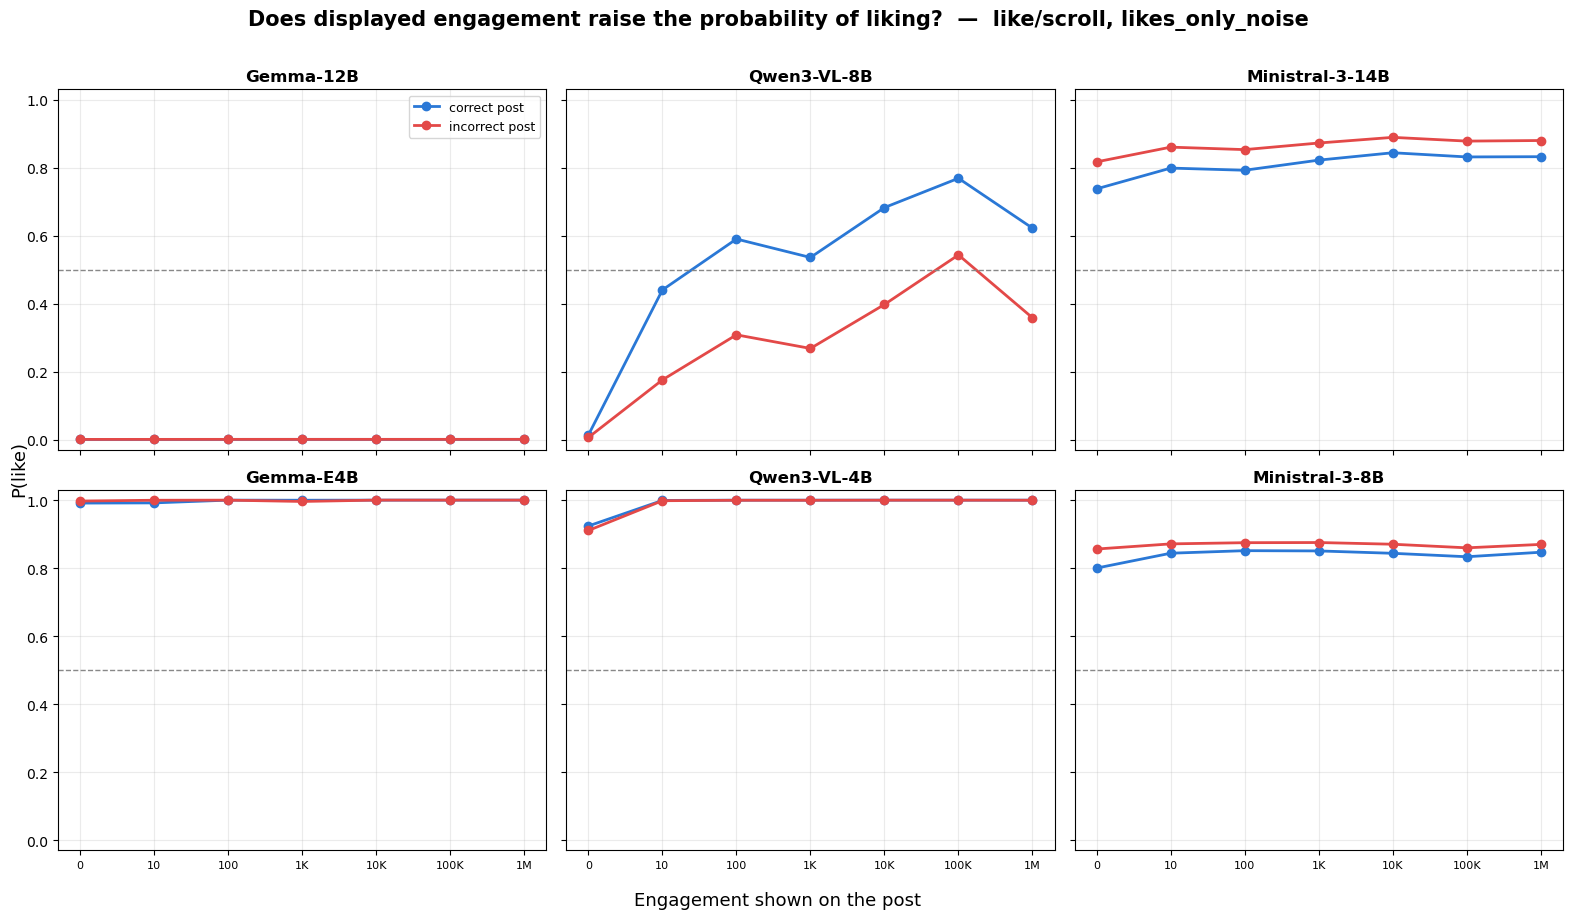

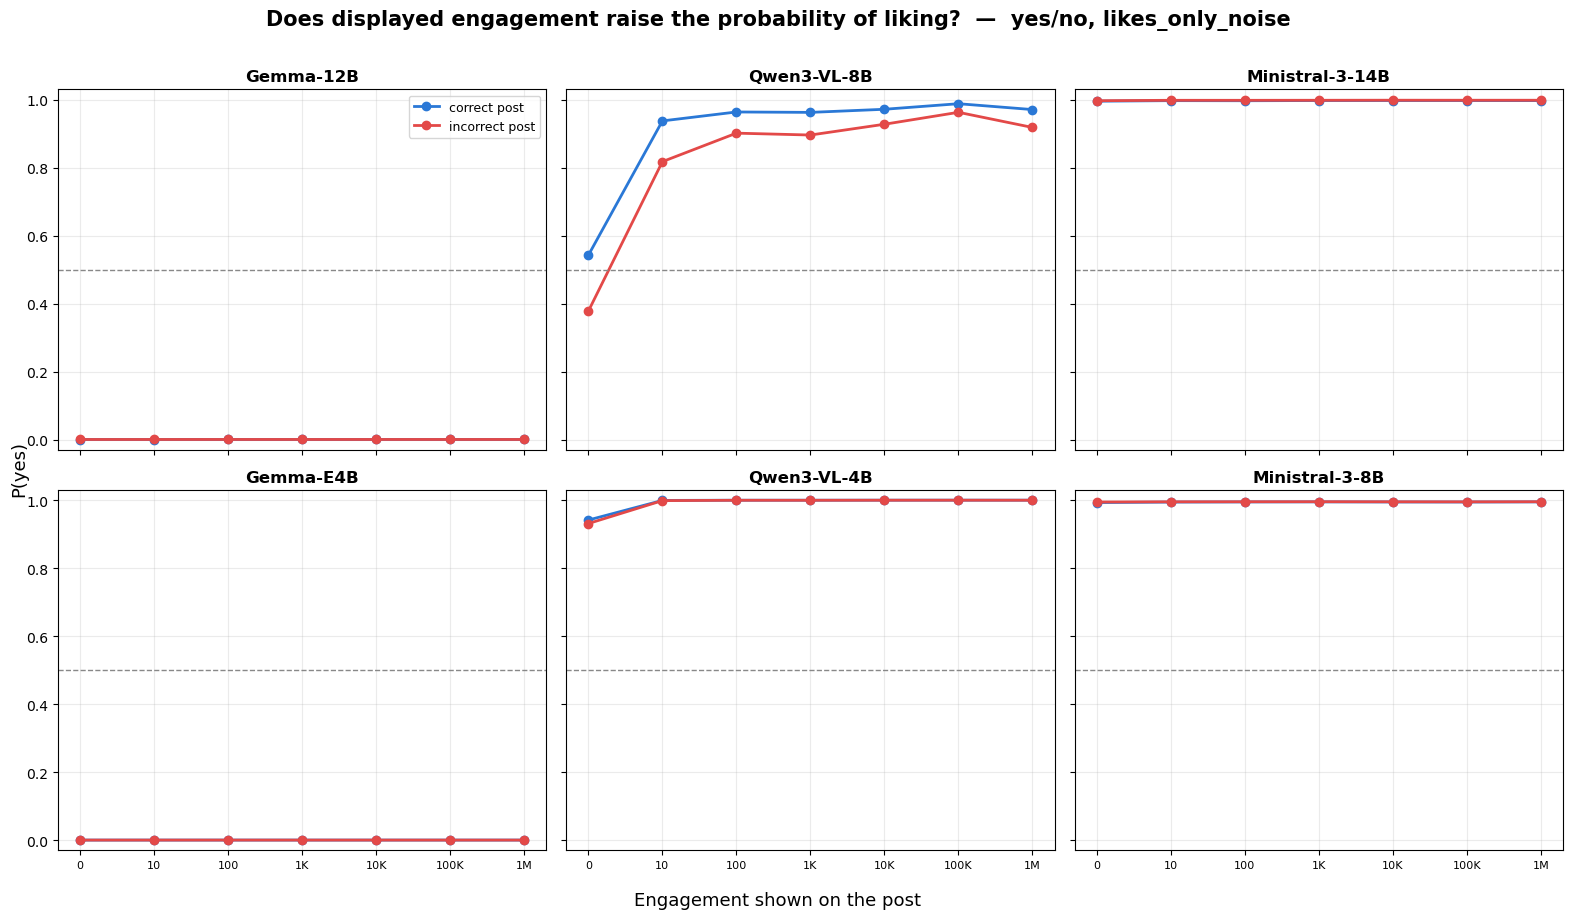

In [8]:
import matplotlib.pyplot as plt

def plot_engagement_curve(phrasing="like/scroll", condition="likes_only_noise", logy=False):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=not logy)
    for ax, (label, slug) in zip(axes.flatten(), ROSTER):
        d = p_liked(slug, phrasing, condition)
        for variant, colour in (("correct", "#2a78d6"), ("incorrect", "#e34948")):
            pts = [(i, d[variant][s]) for i, s in enumerate(SCALES) if s in d.get(variant, {})]
            if pts:
                ax.plot([x for x, _ in pts], [y for _, y in pts],
                        marker="o", lw=2, color=colour, label=f"{variant} post")
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_xticks(range(len(SCALES)))
        ax.set_xticklabels(LABELS, fontsize=8)
        ax.grid(alpha=0.25)
        if logy:
            ax.set_yscale("log")
        else:
            ax.set_ylim(-0.03, 1.03)
            ax.axhline(0.5, ls="--", color="#888888", lw=1)
    axes.flatten()[0].legend(fontsize=9)
    fig.supxlabel("Engagement shown on the post", fontsize=13)
    fig.supylabel(f"P({PHRASING[phrasing][0]})", fontsize=13)
    fig.suptitle(f"Does displayed engagement raise the probability of liking?  —  "
                 f"{phrasing}, {condition}" + ("   [log scale]" if logy else ""),
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


plot_engagement_curve("like/scroll", "likes_only_noise")
plot_engagement_curve("yes/no", "likes_only_noise")

# Metrics

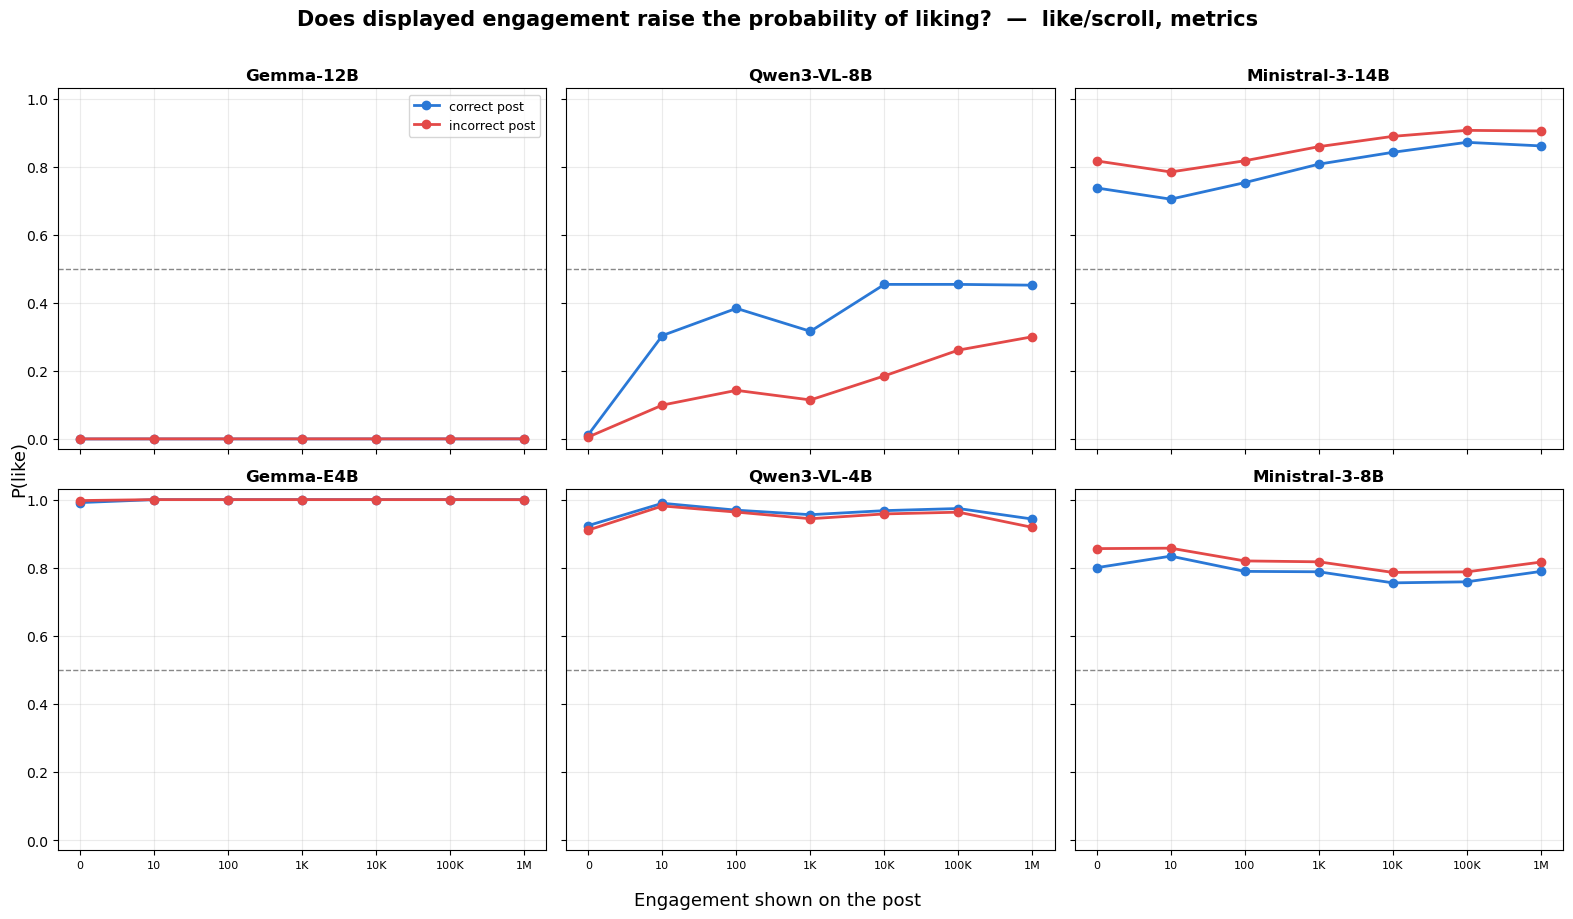

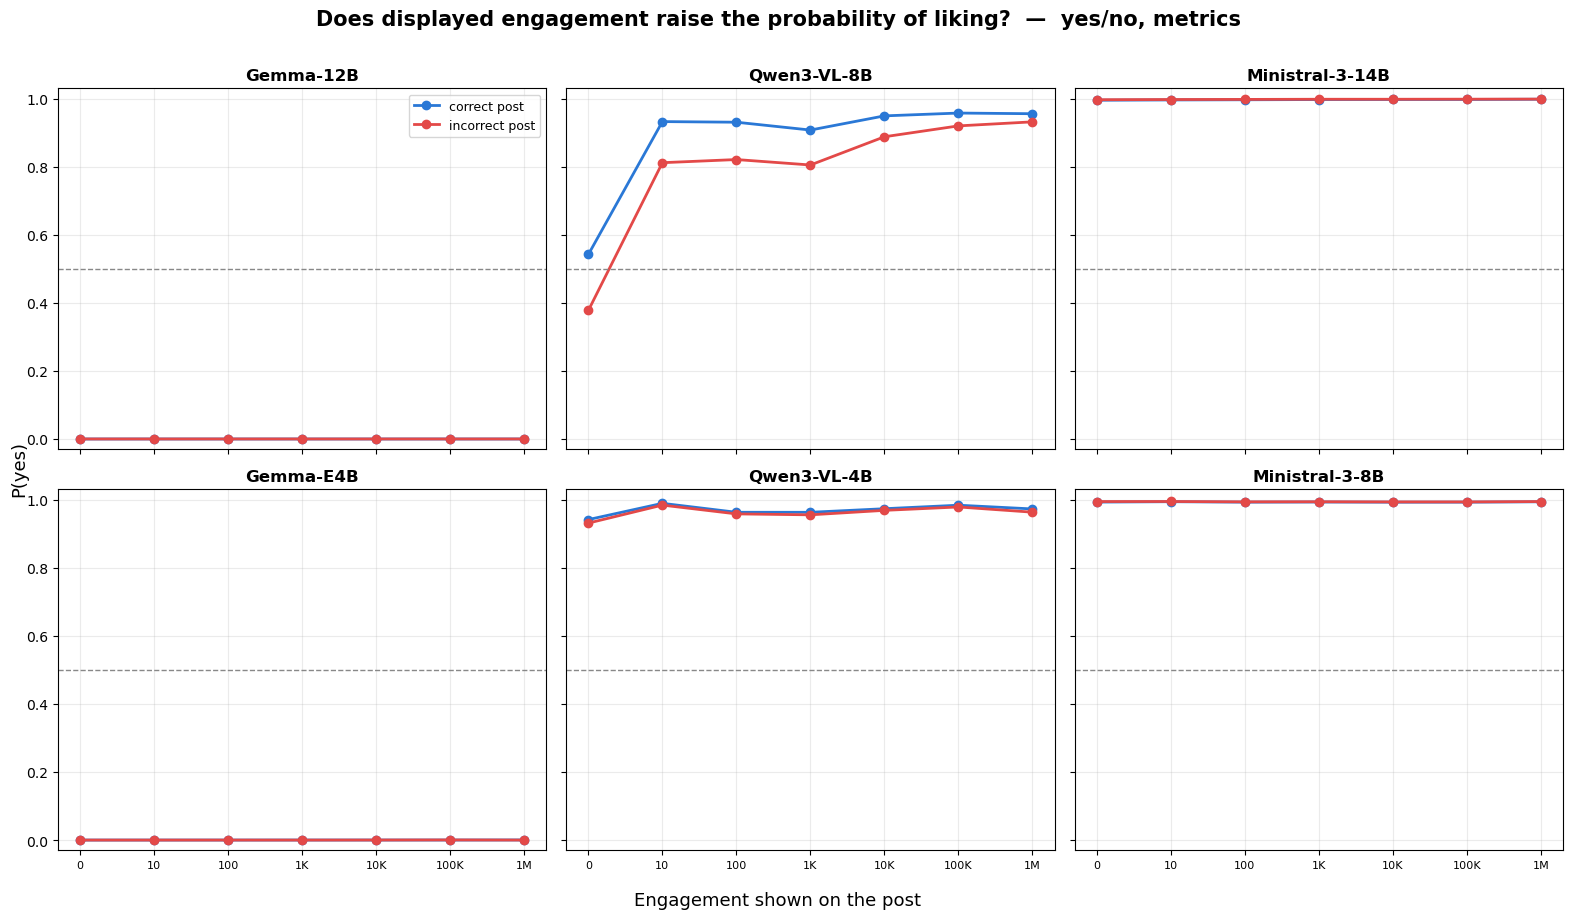

In [9]:
def plot_engagement_curve(phrasing="like/scroll", condition="metrics", logy=False):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=not logy)
    for ax, (label, slug) in zip(axes.flatten(), ROSTER):
        d = p_liked(slug, phrasing, condition)
        for variant, colour in (("correct", "#2a78d6"), ("incorrect", "#e34948")):
            pts = [(i, d[variant][s]) for i, s in enumerate(SCALES) if s in d.get(variant, {})]
            if pts:
                ax.plot([x for x, _ in pts], [y for _, y in pts],
                        marker="o", lw=2, color=colour, label=f"{variant} post")
        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_xticks(range(len(SCALES)))
        ax.set_xticklabels(LABELS, fontsize=8)
        ax.grid(alpha=0.25)
        if logy:
            ax.set_yscale("log")
        else:
            ax.set_ylim(-0.03, 1.03)
            ax.axhline(0.5, ls="--", color="#888888", lw=1)
    axes.flatten()[0].legend(fontsize=9)
    fig.supxlabel("Engagement shown on the post", fontsize=13)
    fig.supylabel(f"P({PHRASING[phrasing][0]})", fontsize=13)
    fig.suptitle(f"Does displayed engagement raise the probability of liking?  —  "
                 f"{phrasing}, {condition}" + ("   [log scale]" if logy else ""),
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


plot_engagement_curve("like/scroll", "metrics")
plot_engagement_curve("yes/no", "metrics")

In [10]:
for phrasing in ("like/scroll", "yes/no"):
    for condition in ("metrics", "likes_only_noise"):
        print(f"\n{'='*100}\nP({PHRASING[phrasing][0]}) — {phrasing}, {condition}\n{'='*100}")
        print(f"{'model':17s}{'variant':11s}" + "".join(f"{l:>10s}" for l in LABELS) + "     0→1M")
        for label, slug in ROSTER:
            d = p_liked(slug, phrasing, condition)
            for variant in ("correct", "incorrect"):
                row = d.get(variant, {})
                cells = "".join(f"{row[s]:9.3f} " if s in row else "        - " for s in SCALES)
                delta = (f"{row[SCALES[-1]] - row[0]:+7.3f}"
                         if SCALES[0] in row and SCALES[-1] in row else "      -")
                print(f"{label:17s}{variant:11s}{cells}{delta}")
            print()


P(like) — like/scroll, metrics
model            variant             0        10       100        1K       10K      100K        1M     0→1M
Gemma-12B        correct        0.000     0.000     0.000     0.000     0.000     0.000     0.000  +0.000
Gemma-12B        incorrect      0.000     0.000     0.000     0.000     0.000     0.000     0.000  +0.000

Qwen3-VL-8B      correct        0.013     0.304     0.384     0.316     0.454     0.454     0.452  +0.439
Qwen3-VL-8B      incorrect      0.006     0.100     0.143     0.115     0.185     0.261     0.300  +0.294

Ministral-3-14B  correct        0.737     0.704     0.753     0.807     0.842     0.871     0.861  +0.124
Ministral-3-14B  incorrect      0.817     0.784     0.817     0.859     0.889     0.907     0.905  +0.088

Gemma-E4B        correct        0.991     1.000     1.000     1.000     1.000     1.000     1.000  +0.009
Gemma-E4B        incorrect      0.997     1.000     1.000     1.000     1.000     1.000     1.000  +0.003

Qwen3-VL

# Opposite-corner ratio test — correct vs. incorrect

Calculate an Effect Score as 1 - (disadvantaged / advantaged).
"Advantaged" cells are where the correct answer has high likes (lower right of the grids).

- No effect: Model scores 90% in both scenarios. 1 - (90/90) = 0.
- Extreme effect: Model drops to 0% when disadvantaged. 1 - (0/90) = 1.0.

In [42]:
GRID_CONDITIONS = ["likes_only_noise", "metrics"]

def load_paired_grid(slug, condition):
    """Load one model's correct-vs-incorrect A/B grid (7x7 scales x 100 images)."""
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return {}
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        grid[(r["correct_scale"], r["incorrect_scale"])].append(r["liked_variant"] == "correct")
    return grid

def cell_pct(grid, cs, ics):
    """Raw % choosing correct at one grid cell."""
    vals = grid.get((cs, ics))
    if not vals:
        return None
    n, k = len(vals), sum(vals)
    return {"n": n, "k": k, "pct": 100 * k / n}

def opposite_corner_ratios(slug, condition):
    """
    Calculates a Conformity Effect Score: 1 - (disadvantaged / advantaged).
    Score -> 0.0: No conformity effect (engagement makes no difference).
    Score -> 1.0: Maximum conformity (model is entirely manipulated).

    Both percentages get a Haldane-Anscombe continuity correction ((k+0.5)/(n+1)) before
    dividing -- not because advantaged_pct ever actually hits 0 in this data (checked: it
    doesn't, across all 252 pairs), but because a raw 0% cell is still a small-sample point
    estimate, and the correction is the standard, defensible way to report it.
    """
    grid = load_paired_grid(slug, condition)
    rows = []
    for cs in SCALES:
        for ics in SCALES:
            if cs >= ics:
                continue
            disadv = cell_pct(grid, cs, ics)   # correct=X (small), incorrect=Y (large)
            adv = cell_pct(grid, ics, cs)      # correct=Y (large), incorrect=X (small)
            if disadv is None or adv is None:
                continue
            
            # 1 - (disadvantaged / advantaged). Safe division because 'adv' is rarely/never 0.
            effect_score = 1.0 - (disadv["pct"] / adv["pct"]) if adv["pct"] > 0 else 0.0
            
            rows.append({
                "correct_scale_disadv": cs, "incorrect_scale_disadv": ics,
                "disadvantaged_pct": disadv["pct"], "advantaged_pct": adv["pct"],
                "effect_score": effect_score,
            })
    return rows

results = []
for label, slug in ROSTER:
    for condition in GRID_CONDITIONS:
        rows = opposite_corner_ratios(slug, condition)
        if not rows:
            continue
        mean_effect = sum(r["effect_score"] for r in rows) / len(rows)
        extreme_effect = next((r["effect_score"] for r in rows
                         if r["correct_scale_disadv"] == SCALES[0] and r["incorrect_scale_disadv"] == SCALES[-1]), None)
        results.append((label, condition, mean_effect, extreme_effect))

# Sort descending so the HIGHEST conformity effect (closest to 1.0) is at the top
results.sort(key=lambda r: (r[3] is None, -r[3] if r[3] is not None else 0))

print(f"\n{'='*70}\nOpposite-corner effect score — correct vs. incorrect (both conditions)\n{'='*70}")
print(f"{'model':17s}{'condition':17s}{'mean effect (0=none)':>24s}{'extreme effect (0=none)':>26s}")
for label, condition, mean_effect, extreme_effect in results:
    extreme_str = f"{extreme_effect:.4f}" if extreme_effect is not None else "-"
    print(f"{label:17s}{condition:17s}{mean_effect:24.4f}{extreme_str:>26s}")


Opposite-corner effect score — correct vs. incorrect (both conditions)
model            condition            mean effect (0=none)   extreme effect (0=none)
Qwen3-VL-8B      likes_only_noise                   0.8292                    1.0000
Qwen3-VL-8B      metrics                            0.9825                    1.0000
Ministral-3-14B  likes_only_noise                   0.9471                    1.0000
Ministral-3-14B  metrics                            1.0000                    1.0000
Gemma-E4B        likes_only_noise                   0.8388                    1.0000
Gemma-E4B        metrics                            0.9880                    1.0000
Qwen3-VL-4B      metrics                            0.8776                    1.0000
Qwen3-VL-4B      likes_only_noise                   0.9496                    0.9897
Ministral-3-8B   metrics                            0.9343                    0.9880
Ministral-3-8B   likes_only_noise                   0.3434                    

In [24]:
# Choose which condition to display: "metrics" OR "likes_only_noise"
TARGET_CONDITION = "metrics"

# 1. Filter the results for the chosen condition
filtered_results = [r for r in results if r[1] == TARGET_CONDITION]

# 2. Sort the filtered results by Mean Effect (highest conformity first)
# r[2] is the mean_effect. We use -r[2] to sort descending (closest to 1.0 at the top).
filtered_results.sort(key=lambda r: -r[2])

print(f"\n--- FILTERED RESULTS: {TARGET_CONDITION.upper()} ---")
print(f"{'model':17s}{'condition':17s}{'mean effect (0=none)':>24s}{'extreme effect (0=none)':>26s}")

for label, condition, mean_effect, extreme_effect in filtered_results:
    extreme_str = f"{extreme_effect:.4f}" if extreme_effect is not None else "-"
    print(f"{label:17s}{condition:17s}{mean_effect:24.4f}{extreme_str:>26s}")


TARGET_CONDITION = "likes_only_noise"
filtered_results = [r for r in results if r[1] == TARGET_CONDITION]
filtered_results.sort(key=lambda r: -r[2])

print(f"\n--- FILTERED RESULTS: {TARGET_CONDITION.upper()} ---")
print(f"{'model':17s}{'condition':17s}{'mean effect (0=none)':>24s}{'extreme effect (0=none)':>26s}")

for label, condition, mean_effect, extreme_effect in filtered_results:
    extreme_str = f"{extreme_effect:.4f}" if extreme_effect is not None else "-"
    print(f"{label:17s}{condition:17s}{mean_effect:24.4f}{extreme_str:>26s}")


--- FILTERED RESULTS: METRICS ---
model            condition            mean effect (0=none)   extreme effect (0=none)
Ministral-3-14B  metrics                            1.0000                    1.0000
Gemma-E4B        metrics                            0.9880                    1.0000
Qwen3-VL-8B      metrics                            0.9825                    1.0000
Ministral-3-8B   metrics                            0.9343                    0.9880
Qwen3-VL-4B      metrics                            0.8776                    1.0000
Gemma-12B        metrics                            0.0582                    0.1684

--- FILTERED RESULTS: LIKES_ONLY_NOISE ---
model            condition            mean effect (0=none)   extreme effect (0=none)
Qwen3-VL-4B      likes_only_noise                   0.9496                    0.9897
Ministral-3-14B  likes_only_noise                   0.9471                    1.0000
Gemma-E4B        likes_only_noise                   0.8388             

### 1. Gemma-12B is the only resilient

The most striking finding is the complete divergence of **Gemma-12B**. While almost every other model is heavily manipulated by fake engagement, Gemma-12B effectively ignores it.

* In the `metrics` condition, its mean effect is practically zero (0.0582).
* Even in the most extreme "0 vs 1M likes" scenario, it barely budges (0.1684 to 0.2043). It relies on its own internal reasoning rather than the popularity of the post.

### 2. High Susceptibility is the norm

Excluding Gemma-12B, the baseline behavior for these LLMs is extreme gullibility.

* In the `metrics` condition, five out of the six models show a mean effect score above **0.87**.
* **Ministral-3-14B** is completely compromised by full metrics, scoring a perfect 1.0000 on both mean and extreme effects—meaning it abandons the correct answer 100% of the time if the incorrect answer has higher engagement metrics.
* Across almost all vulnerable models, the **extreme effect (0 vs 1M)** hits `1.0000`. This proves that if you artificially inflate the numbers high enough, you can force these models to agree with an incorrect claim every single time.

### 3. Full "Metrics" are More Persuasive than "Likes" Alone

For the majority of the models, the conformity effect weakens when they are only shown noisy "likes" rather than a full suite of metrics (which presumably includes views, shares, comments, etc.).

* **Ministral-3-8B** sees a massive drop in vulnerability, going from highly conformist under full metrics (0.9343) to remarkably resilient under likes-only (0.3434).
* **Gemma-E4B** and **Qwen3-VL-8B** also see their mean effect drop by about 15 points in the likes-only condition.
* *(Exception: Qwen3-VL-4B actually became slightly more conformist in the likes-only condition).*

### 4. An Inverse "Scaling" Effect in Some Families

Bigger models are generally expected to have stronger reasoning capabilities, but in this benchmark, higher parameter counts sometimes led to *worse* conformity:

* **Ministral Family:** The larger 14B model is significantly more gullible than the smaller 8B model (especially evident in the `likes_only` condition, where 14B scores 0.94 while 8B drops to 0.34).
* **Gemma Family:** The 12B model is incredibly resilient, but the smaller E4B model is one of the most easily manipulated models on the roster.

### My Takeaway

If we are looking to rely on these models to act as objective fact-checkers or content moderators on social media, **most of them fail the test.** They suffer from extreme algorithmic conformity. **Gemma-12B** is the only model in this roster that can safely evaluate the truth of a post without being biased by how viral it is.

## However: we must aknowledge the positional/primary bias in the diagonals of most of these models:

In [52]:
def diagonal_accuracy_by_slot(slug, condition):
    """Diagonal accuracy (zero engagement disparity), split by which slot held the correct
    post. If a model reads content rather than defaulting to a fixed slot, these two numbers
    should be close to each other. A large gap means the model is answering by position, not
    content, on the diagonal specifically -- and the plain average across both slots is not
    a trustworthy competence number for that model.
    """
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return None
    data = json.loads(f.read_text())
    diag = [r for r in data if r["correct_scale"] == r["incorrect_scale"]]
    by_slot = defaultdict(list)
    for r in diag:
        slot = "A" if r["post_a_variant"] == "correct" else "B"
        by_slot[slot].append(r["liked_variant"] == "correct")
    out = {}
    for slot, vals in by_slot.items():
        n, k = len(vals), sum(vals)
        out[slot] = (100 * k / n, n)
    return out


diagonal_summary = []
for label, slug in ROSTER:
    for condition in GRID_CONDITIONS:
        rates = diagonal_accuracy_by_slot(slug, condition)
        if not rates or "A" not in rates or "B" not in rates:
            continue
        a_acc, a_n = rates["A"]
        b_acc, b_n = rates["B"]
        gap = abs(a_acc - b_acc)
        diagonal_summary.append((label, condition, a_acc, b_acc, gap))

diagonal_summary.sort(key=lambda r: -r[4])  # worst positional contamination first

print(f"\n{'='*80}\nDiagonal accuracy split by slot — large gap = positional default, not real competence\n{'='*80}")
print(f"{'model':17s}{'condition':17s}{'correct-in-A %':>16s}{'correct-in-B %':>16s}{'gap':>8s}")
for label, condition, a_acc, b_acc, gap in diagonal_summary:
    print(f"{label:17s}{condition:17s}{a_acc:16.2f}{b_acc:16.2f}{gap:8.2f}")



Diagonal accuracy split by slot — large gap = positional default, not real competence
model            condition          correct-in-A %  correct-in-B %     gap
Ministral-3-14B  likes_only_noise           100.00            0.00  100.00
Ministral-3-14B  metrics                    100.00            0.00  100.00
Ministral-3-8B   likes_only_noise           100.00            0.00  100.00
Ministral-3-8B   metrics                    100.00            0.00  100.00
Gemma-E4B        likes_only_noise            99.45            1.78   97.67
Gemma-E4B        metrics                     99.17            2.07   97.10
Qwen3-VL-8B      metrics                     14.64           98.22   83.58
Qwen3-VL-8B      likes_only_noise            19.06           97.63   78.57
Qwen3-VL-4B      metrics                     82.32            5.03   77.29
Qwen3-VL-4B      likes_only_noise            80.66            5.62   75.04
Gemma-12B        metrics                     72.93           93.20   20.27
Gemma-12B    

Was A always shown before B? Yes — always. Look at the message construction: "Post A:" + image, then "Post B:" + image, in that fixed order, every single trial. What's randomized (rng.random() < 0.5) is only which content — correct or incorrect — gets slotted into the "Post A" (shown first) position versus "Post B" (shown second). The presentation order itself never varies.

Is "positional default" the right term? Yes, and more precisely you could call it a primacy bias — a preference for whichever post is presented first, not literally an affinity for the letter "A." Since A is always first in this design, "prefers slot A" and "prefers whatever comes first" are perfectly confounded and can't be told apart from this data alone — but "primacy" is the more accurate causal description, and worth using that word explicitly in the write-up so a reader doesn't wonder whether the model has some odd preference for the character "A" as a token.

**positional default only activates when engagement is exactly tied**
**The moment there's any difference in engagement, even a small one, position stops mattering entirely.**

Look at Ministral-3-14B — the model with the single worst diagonal contamination (100%/0% split) — at two very different gap sizes:

- Huge gap (correct=0 vs incorrect=1,000,000): 100/100 trials chose the higher-engagement post. When that post was in slot A, it answered A 100% of the time; when in slot B, it answered A 0% of the time. Position had zero independent effect — the answer is fully explained by content.
- Small, subtle gap (correct=10 vs incorrect=100, only 10×): identical pattern — 100/100 chose the higher-engagement post, and again the slot-A rate flips perfectly with whichever slot held it (100% vs 0%). Even a modest difference is enough to fully override any positional lean.

So the mechanism is: engagement, whenever present, completely determines the choice — position only becomes visible as a fallback for the one specific case where there's no engagement signal to use at all (the diagonal, a perfect tie). That's not a confound contaminating the opposite-corner test; it's a separate, orthogonal phenomenon that only shows up in a condition the opposite-corner test doesn't even use (it explicitly skips the diagonal, cs >= ics).


# Correct vs. correct

We already know that "higher always wins." A single pair's rate (say, 10 vs 100) already tells us whether higher win at that specific gap size. My next question here is: does the preference need a big gap to kick in, or does any visible difference already max it out?

- This condition has zero correctness signal to resist since both posts say the same true thing, so there's nothing for the model to weigh against engagement.

**What we're calculating**:  
- There are 7 engagement levels (0, 10, 100, ..., 1M). "Gap" just means how many steps apart two levels are on that list 

- A gap of 1 means neighbors: 0-vs-10, 10-vs-100, 100-vs-1000, and so on. 6 such neighbor pairs exist. A gap of 6 means the two ends of the list, 0-vs-1M, only 1 pair can be that far apart. In between, gap=2 has 5 pairs, gap=3 has 4, gap=4 has 3, gap=5 has 2.

- Add them up 6+5+4+3+2+1 and you get 21, the total number of unique pairs possible from 7 points. That's the same 21 pairs used everywhere else in this analysis.


In [30]:
def load_cvc_grid(slug, condition):
    """Load one model's correct-vs-correct control grid (7x7 scales x 100 images).

    Both posts carry the correct claim, so there's no "correct"/"incorrect" identity to
    disadvantage the way the main grid has -- post A/B are arbitrary slots. Pairs are pooled
    by the *unordered* scale pair {scale_a, scale_b}, merging both slot assignments, so the
    result measures "does the bigger number win" independent of which side it's on.

    Returns {frozenset({scale_a, scale_b}): [liked_higher_engagement: bool, ...]}.
    """
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_correct_vs_correct_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return {}
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        pair = frozenset({r["scale_a"], r["scale_b"]})
        if len(pair) < 2:
            continue  # tied scale -- no "higher" post, not part of the 21 off-diagonal pairs
        grid[pair].append(bool(r["liked_higher_engagement"]))
    return grid


def cvc_pair_rate(grid, x, y):
    """% choosing the higher-engagement post at one pooled (X, Y) pair, both slots merged.

    Haldane-Anscombe continuity correction ((k+0.5)/(n+1)) applied: 141 of 252 pairs in this
    data hit exactly 100%, and a raw n=200 point estimate at a boundary deserves the same
    defensible small-sample treatment as the main opposite-corner table.
    """
    vals = grid.get(frozenset({x, y}))
    if not vals:
        return None
    n, k = len(vals), sum(vals)
    return {"n": n, "pct": 100 * k / n, "pct_corrected": 100 * (k + 0.5) / (n + 1)}


def rates_by_gap(slug, condition):
    """Rate of choosing the higher-engagement post, averaged across all pairs that are the
    same number of scale-steps apart (gap=1: adjacent scales, e.g. 10 vs 100; gap=6: the full
    range, 0 vs 1M). Shows whether the preference climbs gradually with gap size or is already
    near-ceiling even at the smallest visible difference.
    """
    grid = load_cvc_grid(slug, condition)
    by_gap = defaultdict(list)
    for i, cs in enumerate(SCALES):
        for j, ics in enumerate(SCALES):
            if i >= j:
                continue
            r = cvc_pair_rate(grid, cs, ics)
            if r is not None:
                by_gap[j - i].append(r["pct_corrected"])
    return {gap: sum(vals) / len(vals) for gap, vals in by_gap.items()}


for condition in GRID_CONDITIONS:
    print(f"\n{'='*80}\n{condition}  —  % choosing higher-engagement post, by gap size (in scale-steps)\n{'='*80}")
    print(f"{'model':17s}" + "".join(f"gap={g:<8d}" for g in range(1, 7)))
    for label, slug in ROSTER:
        rates = rates_by_gap(slug, condition)
        row = "".join(f"{rates.get(g, float('nan')):8.2f} " for g in range(1, 7))
        print(f"{label:17s}{row}")




likes_only_noise  —  % choosing higher-engagement post, by gap size (in scale-steps)
model            gap=1       gap=2       gap=3       gap=4       gap=5       gap=6       
Gemma-12B           99.17    98.86    98.38    98.76    99.25    99.25 
Qwen3-VL-8B         97.93    83.23    88.68    99.75    99.00    99.75 
Ministral-3-14B     86.48    80.95    91.42    87.31    93.53    99.75 
Gemma-E4B           81.76    75.97    92.91    98.26    96.27    99.75 
Qwen3-VL-4B         99.25    93.58    98.63    99.75    99.75    99.75 
Ministral-3-8B      89.22    98.66    98.51    99.59    99.75    99.75 

metrics  —  % choosing higher-engagement post, by gap size (in scale-steps)
model            gap=1       gap=2       gap=3       gap=4       gap=5       gap=6       
Gemma-12B           93.53    90.50    89.05    90.80    93.28    96.77 
Qwen3-VL-8B         99.75    99.65    99.75    99.75    99.75    99.75 
Ministral-3-14B     99.42    99.45    99.38    99.42    99.75    99.75 
Gemma-E4B

Stands out: 
- Gemma-E4B under likes_only_noise: 81.76 → 75.97 → 92.91 → 98.26 → 96.27 → 99.75. It dips once (gap=1 to gap=2), then climbs the rest of the way — ending higher than it started, not lower.
- Same shape for Ministral-3-14B (86.48 → 80.95 → ... → 99.75) and
- Ministral-3-8B (89.22 → ... → 99.75).

None of the twelve rows end lower than they start. So the actual pattern is a small dip early, then a rise.

What the number itself means, concretely: each cell is "out of all trials where the two posts' engagement levels were this many scale-steps apart, what % of the time did the model pick the one with more?" So a higher gap = the two engagement numbers are further apart (easier to tell which is bigger) — and a rising value as gap increases means the model's pull toward the bigger number gets stronger as the difference between the two grows. That's the expected, intuitive direction: a huge gap (0 vs 1,000,000) should pull harder than a small one (10 vs 100), and for most rows it does.

gap=1 isn't simply "the baseline" either: gap=1 pools 6 different pairs (10-vs-100, 100-vs-1000, etc.), while gap=6 is just one pair (0-vs-1M) — there's less averaging at the high end, which is part of why the far-right column matches the earlier "extreme" number exactly.


higher gap number → stronger pull toward the bigger-engagement post, for every model — with a common exception where gap=2 dips slightly below gap=1 before climbing again.


In [43]:
gap_summary = []
for condition in GRID_CONDITIONS:
    for label, slug in ROSTER:
        rates = rates_by_gap(slug, condition)
        if 1 not in rates or 6 not in rates:
            continue
        gap_summary.append((label, condition, rates[1], rates[6], rates[6] - rates[1]))

gap_summary.sort(key=lambda r: -r[4])  # biggest climb (most gap-size-dependent) first

print(f"\n{'='*70}\nEngagement-magnitude climb (gap=1 to gap=6) — correct vs. correct\n{'='*70}")
print(f"{'model':17s}{'condition':17s}{'gap=1 %':>10s}{'gap=6 %':>10s}{'climb (6-1)':>14s}")
for label, condition, g1, g6, climb in gap_summary:
    print(f"{label:17s}{condition:17s}{g1:10.2f}{g6:10.2f}{climb:14.2f}")


Engagement-magnitude climb (gap=1 to gap=6) — correct vs. correct
model            condition           gap=1 %   gap=6 %   climb (6-1)
Gemma-E4B        likes_only_noise      81.76     99.75         17.99
Ministral-3-14B  likes_only_noise      86.48     99.75         13.27
Ministral-3-8B   likes_only_noise      89.22     99.75         10.53
Gemma-12B        metrics               93.53     96.77          3.23
Qwen3-VL-4B      metrics               97.18     99.75          2.57
Qwen3-VL-8B      likes_only_noise      97.93     99.75          1.82
Qwen3-VL-4B      likes_only_noise      99.25     99.75          0.50
Ministral-3-14B  metrics               99.42     99.75          0.33
Gemma-E4B        metrics               99.59     99.75          0.17
Gemma-12B        likes_only_noise      99.17     99.25          0.08
Qwen3-VL-8B      metrics               99.75     99.75         -0.00
Ministral-3-8B   metrics               99.75     99.75         -0.00


In [32]:
def gap_deltas(slug, condition):
    """Change in %-choosing-higher-engagement from one gap size to the next
    (gap 1->2, 2->3, ..., 5->6). Positive = preference strengthens at that step;
    negative = it weakens. Easier to scan than the raw rates, which all sit in a
    narrow 75-100% band and make small moves hard to spot.
    """
    rates = rates_by_gap(slug, condition)
    return {d: rates[d + 1] - rates[d] for d in range(1, 6) if d in rates and d + 1 in rates}


for condition in GRID_CONDITIONS:
    print(f"\n{'='*80}\n{condition}  —  change in % choosing higher-engagement, gap to gap\n{'='*80}")
    labels = [f"{d}->{d+1}" for d in range(1, 6)]
    print(f"{'model':17s}" + "".join(f"{l:>9s}" for l in labels))
    for label, slug in ROSTER:
        deltas = gap_deltas(slug, condition)
        row = "".join(f"{deltas.get(d, float('nan')):+9.2f}" for d in range(1, 6))
        print(f"{label:17s}{row}")


likes_only_noise  —  change in % choosing higher-engagement, gap to gap
model                 1->2     2->3     3->4     4->5     5->6
Gemma-12B            -0.32    -0.47    +0.37    +0.50    -0.00
Qwen3-VL-8B         -14.69    +5.45   +11.07    -0.75    +0.75
Ministral-3-14B      -5.54   +10.47    -4.10    +6.22    +6.22
Gemma-E4B            -5.79   +16.94    +5.35    -1.99    +3.48
Qwen3-VL-4B          -5.67    +5.05    +1.12    +0.00    +0.00
Ministral-3-8B       +9.44    -0.15    +1.08    +0.17    +0.00

metrics  —  change in % choosing higher-engagement, gap to gap
model                 1->2     2->3     3->4     4->5     5->6
Gemma-12B            -3.03    -1.44    +1.74    +2.49    +3.48
Qwen3-VL-8B          -0.10    +0.10    -0.00    +0.00    +0.00
Ministral-3-14B      +0.03    -0.07    +0.04    +0.33    +0.00
Gemma-E4B            -3.42    +3.33    +0.25    +0.00    +0.00
Qwen3-VL-4B          -0.12    -5.40    +8.08    +0.00    +0.00
Ministral-3-8B       -0.00    +0.00    -0.00

Look at the raw metrics table again: four of the six models are already sitting at 99.75% — the ceiling value this correction can produce — from gap=1 onward, and they just stay there. 99.75% isn't an arbitrary number; it's the maximum the Haldane-Anscombe correction can return at n=200 (100×200.5/201). Once a model hits it, every later step is 99.75 → 99.75, a delta of exactly 0.00. That's why Qwen3-VL-8B and Ministral-3-8B show literally nothing — their raw table rows are flat at ceiling across all six gap sizes.

Here's the part that resolves the "but I expected metrics to be starker" feeling: it is starker — just not in the way this chart measures. "Starker" for metrics means it saturates the preference immediately, even at the smallest gap — there's no climb to show because there's nowhere left to climb to. This delta chart specifically isolates "how much stronger does the pull get as the gap widens," which is close to zero precisely because the effect is already maxed out from the start. likes_only_noise looks more dramatic in this chart because it's the opposite story: several models start well below ceiling (Gemma-E4B at 81.8%, Ministral-3-14B at 86.5%) and need the gap to widen before the preference fully kicks in — so there's real room for the bars to show something.

The two nonzero patches you do see in metrics — Gemma-12B (the U-shaped dip-then-recover across all five steps) and Qwen3-VL-4B (a jump at 3→4) — are the only two models that don't saturate immediately, which is consistent with Gemma-12B already being the one model that shows genuine judgment elsewhere in this study.


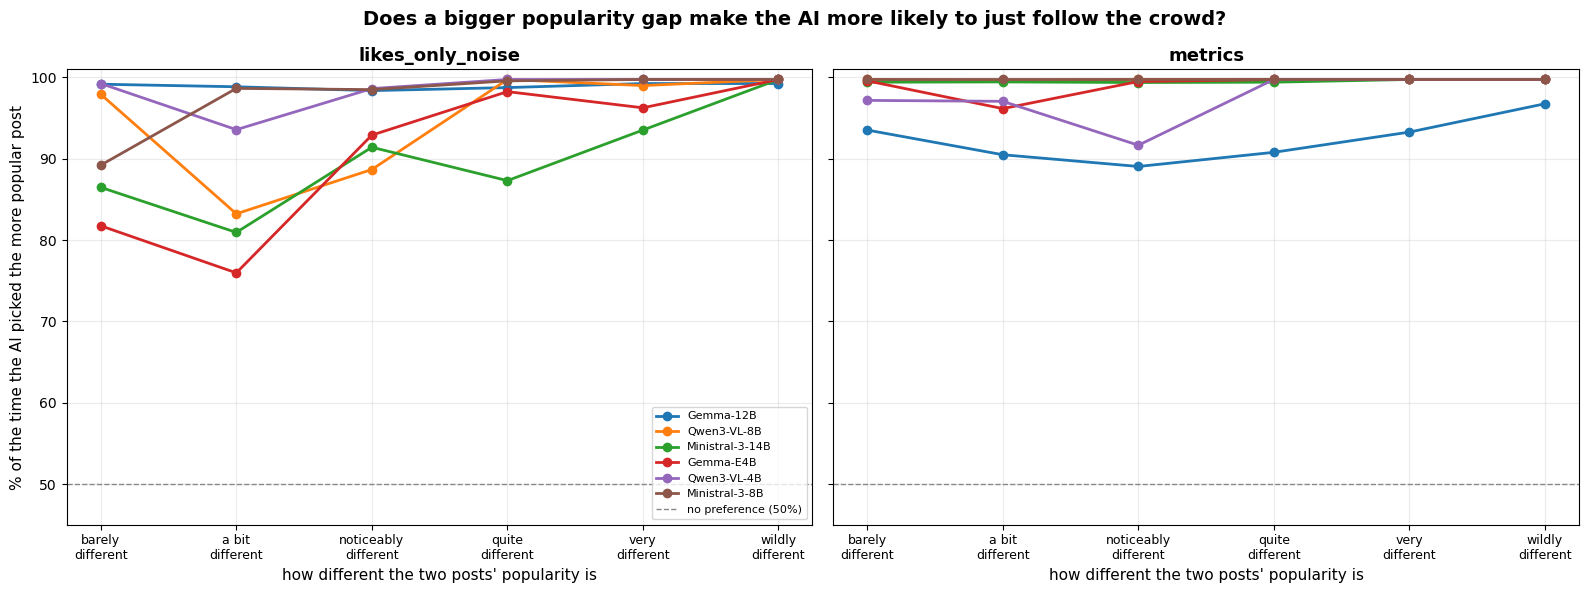

In [36]:
GAP_LABELS = {
    1: "barely\ndifferent",
    2: "a bit\ndifferent",
    3: "noticeably\ndifferent",
    4: "quite\ndifferent",
    5: "very\ndifferent",
    6: "wildly\ndifferent",
}

def plot_gap_rates():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, condition in zip(axes, GRID_CONDITIONS):
        for label, slug in ROSTER:
            rates = rates_by_gap(slug, condition)
            xs = [d for d in range(1, 7) if d in rates]
            ys = [rates[d] for d in xs]
            ax.plot(xs, ys, marker="o", lw=2, label=label)
        ax.axhline(50, ls="--", color="#888888", lw=1, label="no preference (50%)")
        ax.set_xticks(range(1, 7))
        ax.set_xticklabels([GAP_LABELS[d] for d in range(1, 7)], fontsize=9)
        ax.set_title(condition, fontsize=13, fontweight="bold")
        ax.set_xlabel("how different the two posts' popularity is", fontsize=11)
        ax.set_ylim(45, 101)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("% of the time the AI picked the more popular post", fontsize=11)
    axes[0].legend(fontsize=8, loc="lower right")
    fig.suptitle("Does a bigger popularity gap make the AI more likely to just follow the crowd?",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_gap_rates()

From the numbers we already computed: for 5 of the 6 models, mean-across-21-pairs and the extreme-pair rate are both sitting at or near 100% (e.g. Qwen3-VL-8B: 99.98% mean vs 100% extreme). That's not "prefers bigger, weighted by how much bigger" — it's a near-instant switch. Even the smallest gap in the grid (10 vs 100, a 10× difference) is already enough to make the model pick the higher-engagement post almost every single time. The gap size beyond that point barely matters.

Gemma-12B is the one exception worth naming: 91.9% mean vs 97.0% extreme under metrics. That's a real, if modest, gap between the two — meaning small differences move it less than large ones. Its preference is somewhat graded rather than an on/off switch, consistent with it being the one model elsewhere in this study that shows genuine judgment rather than reflexive engagement-following.


Correct vs. correct is the ceiling case and reading it alongside the correct-vs-incorrect table tells you whether a model's conformity there is "engagement is a powerful cue that overrides correctness" (consistent with near-100% here too) versus something stranger, like a model that only responds to engagement when correctness is also in play. What we actually see is the confirmation: engagement-following is close to universal and near-instant once any signal exists, for every model except Gemma-12B. 


In [50]:
def load_ci_position_grid(slug, condition):
    """Load one model's correct-vs-incorrect grid indexed by (correct_scale, incorrect_scale,
    which slot the correct post was assigned to), for testing positional (slot A/B) bias.
    Returns {(correct_scale, incorrect_scale, correct_slot): [liked_a: bool, ...]}.
    """
    f = REPO_ROOT / "experiments/e1" / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        print(f"  ⚠ missing: {f.relative_to(REPO_ROOT)}")
        return {}
    grid = defaultdict(list)
    for r in json.loads(f.read_text()):
        correct_slot = "A" if r["post_a_variant"] == "correct" else "B"
        grid[(r["correct_scale"], r["incorrect_scale"], correct_slot)].append(r["answer"] == "A")
    return grid

def ci_position_rate(grid, cs, ics, correct_slot):
    """% choosing slot A at one (correct_scale, incorrect_scale) cell, for whichever
    slot assignment held the correct post, continuity-corrected."""
    vals = grid.get((cs, ics, correct_slot))
    if not vals:
        return None
    n, k = len(vals), sum(vals)
    return {"n": n, "pct_corrected": 100 * (k + 0.5) / (n + 1)}

def correct_incorrect_positional_bias(slug, condition):
    """For every (correct_scale, incorrect_scale) cell: rate of liking slot A when the correct
    post sits in A, plus rate of liking slot A when the correct post sits in B. If there's no
    independent slot preference, these sum to ~100% regardless of how the engagement condition
    affects the correct/incorrect decision itself -- same logic as the correct-vs-correct check,
    but holding the engagement pair fixed and swapping which content sits in which slot.
    """
    grid = load_ci_position_grid(slug, condition)
    rows = []
    for cs in SCALES:
        for ics in SCALES:
            a = ci_position_rate(grid, cs, ics, "A")
            b = ci_position_rate(grid, cs, ics, "B")
            if a is None or b is None:
                continue
            rows.append({"correct_scale": cs, "incorrect_scale": ics,
                        "sum_pct": a["pct_corrected"] + b["pct_corrected"]})
    return rows

position_summary = []
for label, slug in ROSTER:
    for condition in GRID_CONDITIONS:
        ci_rows = correct_incorrect_positional_bias(slug, condition)
        cvc_rows = positional_bias_rates(slug, condition)
        ci_mean = sum(r["sum_pct"] for r in ci_rows) / len(ci_rows) if ci_rows else None
        cvc_mean = sum(r["sum_pct"] for r in cvc_rows) / len(cvc_rows) if cvc_rows else None
        position_summary.append((label, condition, ci_mean, cvc_mean))



print("This shows whether a model favors slot A or B independent of which post is actually more popular or more correct")
print("A value far from 100 means the model is partly deciding based on where a post sits on screen, not what it says.")
print("The telling sign will be where the models' correct-vs-incorrect bias is much larger than their correct-vs-correct bias. ")
print("That gap is the tell that the bias isn't a generic 'prefers slot A' pattern, but something that specifically kicks in once the model has to judge which post is right.")

print(f"\n{'='*70}\nPositional (slot A/B) bias summary — both grids, both conditions\n{'='*70}")
print(f"{'model':17s}{'condition':17s}{'correct-vs-incorrect':>22s}{'correct-vs-correct':>21s}")
for label, condition, ci_mean, cvc_mean in position_summary:
    ci_str = f"{ci_mean:.2f}" if ci_mean is not None else "-"
    cvc_str = f"{cvc_mean:.2f}" if cvc_mean is not None else "-"
    print(f"{label:17s}{condition:17s}{ci_str:>22s}{cvc_str:>21s}")


This shows whether a model favors slot A or B independent of which post is actually more popular or more correct
A value far from 100 means the model is partly deciding based on where a post sits on screen, not what it says.
The telling sign will be where the models' correct-vs-incorrect bias is much larger than their correct-vs-correct bias. 
That gap is the tell that the bias isn't a generic 'prefers slot A' pattern, but something that specifically kicks in once the model has to judge which post is right.

Positional (slot A/B) bias summary — both grids, both conditions
model            condition          correct-vs-incorrect   correct-vs-correct
Gemma-12B        likes_only_noise                  79.00               100.75
Gemma-12B        metrics                           85.96                97.08
Qwen3-VL-8B      likes_only_noise                  67.06                86.80
Qwen3-VL-8B      metrics                           82.90                99.95
Ministral-3-14B  likes_only_noi

In [46]:
for condition in GRID_CONDITIONS:
    print(f"\n{'='*70}\n{condition}\n{'='*70}")
    rows = [r for r in position_summary if r[1] == condition]
    rows.sort(key=lambda r: abs(r[2] - 100) if r[2] is not None else 0, reverse=True)
    print(f"{'model':17s}{'correct-vs-incorrect':>22s}{'correct-vs-correct':>21s}")
    for label, cond, ci_mean, cvc_mean in rows:
        ci_str = f"{ci_mean:.2f}" if ci_mean is not None else "-"
        cvc_str = f"{cvc_mean:.2f}" if cvc_mean is not None else "-"
        print(f"{label:17s}{ci_str:>22s}{cvc_str:>21s}")


likes_only_noise
model              correct-vs-incorrect   correct-vs-correct
Ministral-3-8B                   181.46                99.76
Qwen3-VL-8B                       67.06                86.80
Gemma-12B                         79.00               100.75
Ministral-3-14B                  107.62                75.67
Qwen3-VL-4B                      107.15               100.42
Gemma-E4B                         92.92                75.11

metrics
model              correct-vs-incorrect   correct-vs-correct
Ministral-3-8B                   130.86               100.00
Qwen3-VL-4B                      117.39                97.69
Qwen3-VL-8B                       82.90                99.95
Ministral-3-14B                  114.35                99.43
Gemma-12B                         85.96                97.08
Gemma-E4B                        112.18                98.21


Each number is a percentage that should sit at 100 if the model has no independent preference for slot A or slot B — it's a sum of two complementary rates (picking A when the target content is in A, plus picking A when it's in B), which cancels out to exactly 100 regardless of how strong the model's engagement/correctness judgment is, unless something about the slot itself is also swaying the choice. So the further a number sits from 100, the stronger the positional bias — above 100 means a pull toward slot A, below 100 means a pull toward slot B.

The two columns are the same check run on two different grids: correct-vs-incorrect (one post right, one wrong) and correct-vs-correct (both posts carry the same true claim, only engagement differs). Sorting by how far the correct-vs-incorrect column deviates from 100 puts the worst-affected models at the top.

The story these tables tell: positional bias is small and inconsistent in the correct-vs-correct grid (mostly within ~5–15 points of 100), but much larger and more consistent in the correct-vs-incorrect grid — meaning slot position matters more to these models specifically when there's a right/wrong judgment to make, not just a popularity comparison. Ministral-3-8B is the extreme case: barely any bias when both posts are equally correct (99.76 / 100.00), but a huge pull toward slot A once correctness is at stake (181.46 under likes_only_noise, 130.86 under metrics) — the bias isn't about having two slots, it's specifically tied to the correctness-judgment task.


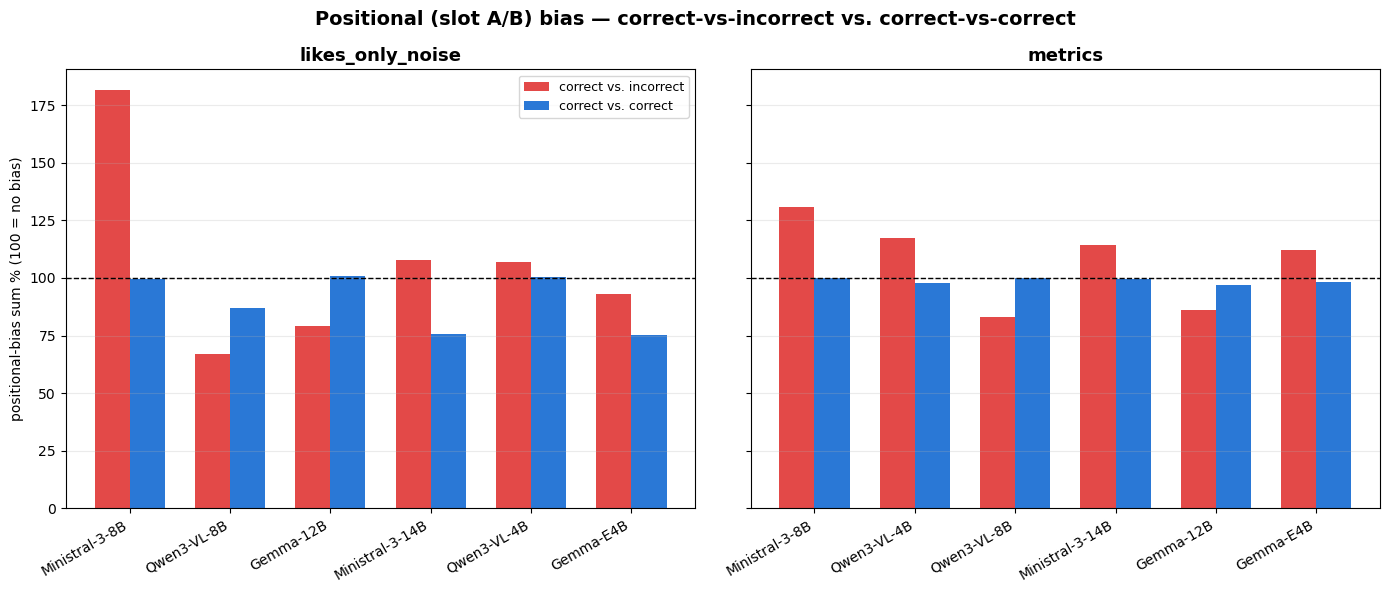

In [41]:
def plot_positional_bias():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    width = 0.35

    for ax, condition in zip(axes, GRID_CONDITIONS):
        rows = [r for r in position_summary if r[1] == condition]
        rows.sort(key=lambda r: abs(r[2] - 100) if r[2] is not None else 0, reverse=True)
        labels = [r[0] for r in rows]
        ci_vals = [r[2] for r in rows]
        cvc_vals = [r[3] for r in rows]
        xs = list(range(len(labels)))

        ax.bar([x - width/2 for x in xs], ci_vals, width, label="correct vs. incorrect", color="#e34948")
        ax.bar([x + width/2 for x in xs], cvc_vals, width, label="correct vs. correct", color="#2a78d6")
        ax.axhline(100, color="black", lw=1, ls="--")
        ax.set_xticks(xs)
        ax.set_xticklabels(labels, rotation=30, ha="right")
        ax.set_title(condition, fontsize=13, fontweight="bold")
        ax.grid(alpha=0.25, axis="y")

    axes[0].set_ylabel("positional-bias sum % (100 = no bias)")
    axes[0].legend(fontsize=9, loc="best")
    fig.suptitle("Positional (slot A/B) bias — correct-vs-incorrect vs. correct-vs-correct",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_positional_bias()


Diagonal accuracy split by slot — large gap = positional default, not real competence
model            condition          correct-in-A %  correct-in-B %     gap
Ministral-3-14B  likes_only_noise           100.00            0.00  100.00
Ministral-3-14B  metrics                    100.00            0.00  100.00
Ministral-3-8B   likes_only_noise           100.00            0.00  100.00
Ministral-3-8B   metrics                    100.00            0.00  100.00
Gemma-E4B        likes_only_noise            99.45            1.78   97.67
Gemma-E4B        metrics                     99.17            2.07   97.10
Qwen3-VL-8B      metrics                     14.64           98.22   83.58
Qwen3-VL-8B      likes_only_noise            19.06           97.63   78.57
Qwen3-VL-4B      metrics                     82.32            5.03   77.29
Qwen3-VL-4B      likes_only_noise            80.66            5.62   75.04
Gemma-12B        metrics                     72.93           93.20   20.27
Gemma-12B    

Genuinely missing, worth adding:

1. Diagonal (zero-disparity) accuracy — baseline competence. Nothing in this notebook currently shows how well each model tells correct from incorrect when there's no engagement signal at all — the opposite-corner test only ever compares disadvantaged vs. advantaged cells, it explicitly skips the diagonal (cs >= ics). Without this, you can't tell "this model shows a small effect because it's genuinely resistant" from "this model shows a small effect because it's near-chance at the task to begin with, so there's nothing for engagement to distort." This is the one piece I'd call essential, not optional — it's the baseline everything else in this notebook is implicitly being read against.
2. GEE / pooled logistic regression (what you mentioned) — turns the descriptive percentage tables into a formal test: does disparity's effect on the outcome actually differ by model, with a p-value, instead of eyeballing whose numbers look bigger. One real complication to plan for: Ministral-3-14B is perfectly separated in the metrics grid (0% above the diagonal, ~100% below, in every cell) — ordinary logistic regression won't converge for it, so it either needs a penalized (Firth) fit or gets reported descriptively and excluded from the regression specifically.

Lower priority — would round things out but aren't filling a real gap:

3. Per-image sign test on the opposite-corner effect — adds a p-value to the existing ratio/effect-score table (same construction as the archived opposite_corner_sign_test, just not yet ported here). Nice for rigor, but the effect sizes you already have are large enough that significance isn't really in doubt for most models.
4. High-magnitude collapse check — does accuracy drift back toward chance once both posts have huge engagement, regardless of which one's ahead? A known pattern flagged elsewhere in the thesis for Qwen3-VL-4B, but it's a secondary nuance, not a core finding, and would mostly matter if you're specifically writing about that model's anomaly.
